# IT2011 – Breast Cancer Wisconsin (Original)

## Progress Review I – Member 2
### Exploratory Data Analysis (EDA)

**Main Responsibility:**
Exploratory Data Analysis

**Techniques Covered:**
- Class Distribution
- Descriptive Statistics
- Histograms
- Boxplots
- Correlation Analysis
- Feature vs Class Analysis

In [3]:
# ============================================
# STEP 2.1 - Import required libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================================
# STEP 3.1 - Load the raw dataset
# ============================================

file_path = "data/raw/breast-cancer-wisconsin.data"

df = pd.read_csv(file_path, header=None)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (699, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [5]:
# ============================================
# STEP 4.1 - Assign meaningful column names
# ============================================

columns = [
    "Sample_ID",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

df.head()

,Sample_ID,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [6]:
# ============================================
# STEP 5.1 - Convert missing value markers
# ============================================

df["Bare_Nuclei"] = df["Bare_Nuclei"].replace("?", np.nan)

df["Bare_Nuclei"] = pd.to_numeric(
    df["Bare_Nuclei"],
    errors="coerce"
)

print("Missing values:")
print(df.isnull().sum())

Missing values:
Sample_ID                       0
Clump_Thickness                 0
Uniformity_Cell_Size            0
Uniformity_Cell_Shape           0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


In [7]:
# ============================================
# STEP 6.1 - Define the predictive features
# ============================================

feature_columns = [
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses"
]

In [8]:
# ============================================
# STEP 7.1 - Analyze class distribution
# ============================================

print(df["Class"].value_counts())

print("\nClass percentages:")
print(df["Class"].value_counts(normalize=True) * 100)

Class
2    458
4    241
Name: count, dtype: int64

Class percentages:
Class
2    65.522175
4    34.477825
Name: proportion, dtype: float64


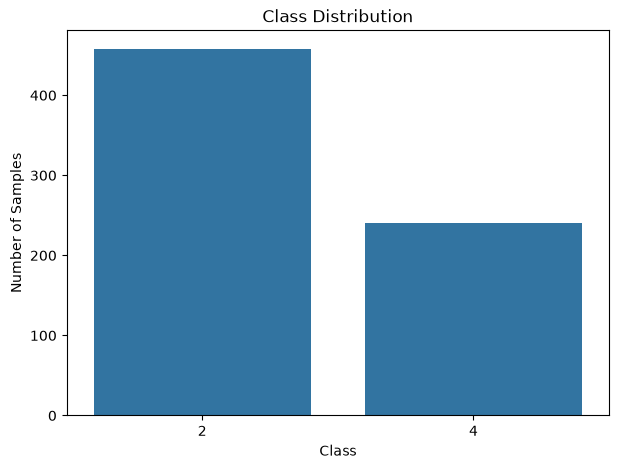

In [9]:
# ============================================
# STEP 7.2 - Visualize class distribution
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Class")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

In [10]:
# ============================================
# STEP 8.1 - Generate descriptive statistics
# ============================================

df[feature_columns].describe()

,Clump_Thickness,Uniformity_Cell_Size,Uniformity_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses
count,699.000000,699.000000,699.000000,699.000000,699.000000,683.000000,699.000000,699.000000,699.000000
mean,4.417740,3.134478,3.207439,2.806867,3.216023,3.544656,3.437768,2.866953,1.589413
std,2.815741,3.051459,2.971913,2.855379,2.214300,3.643857,2.438364,3.053634,1.715078
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


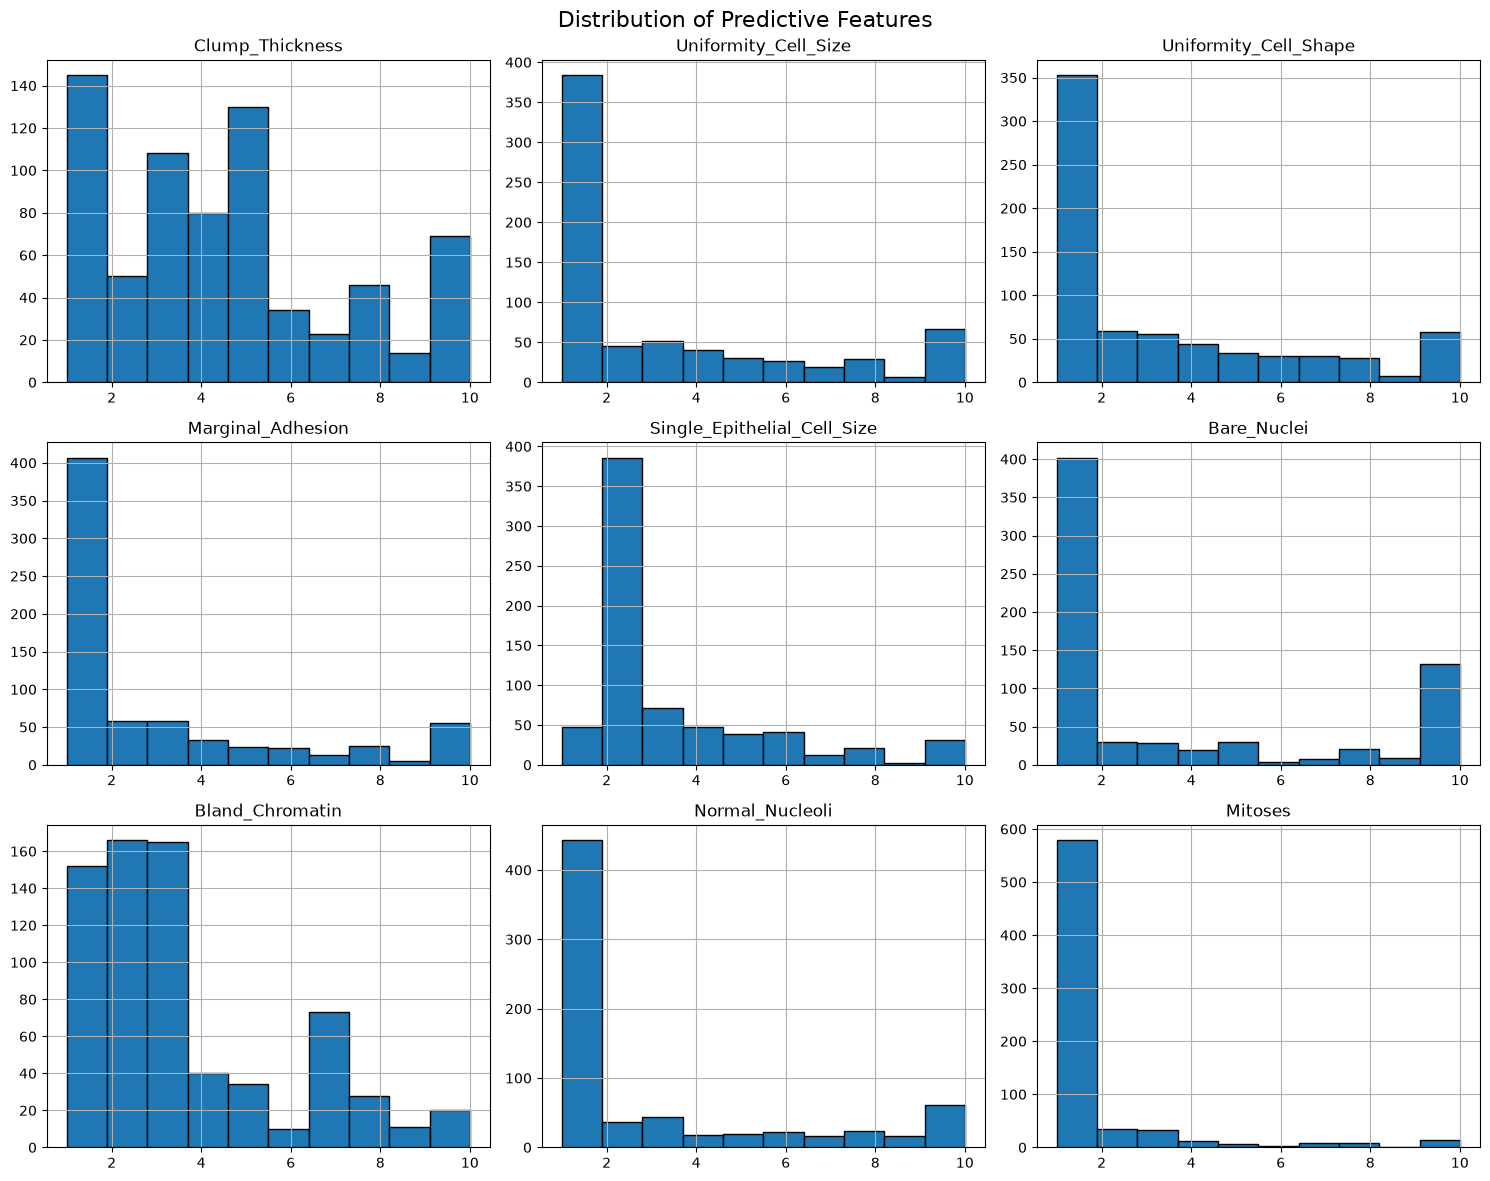

In [11]:
# ============================================
# STEP 9.1 - Plot histograms for all features
# ============================================

df[feature_columns].hist(
    figsize=(15, 12),
    bins=10,
    edgecolor="black"
)

plt.suptitle("Distribution of Predictive Features", fontsize=16)

plt.tight_layout()
plt.show()

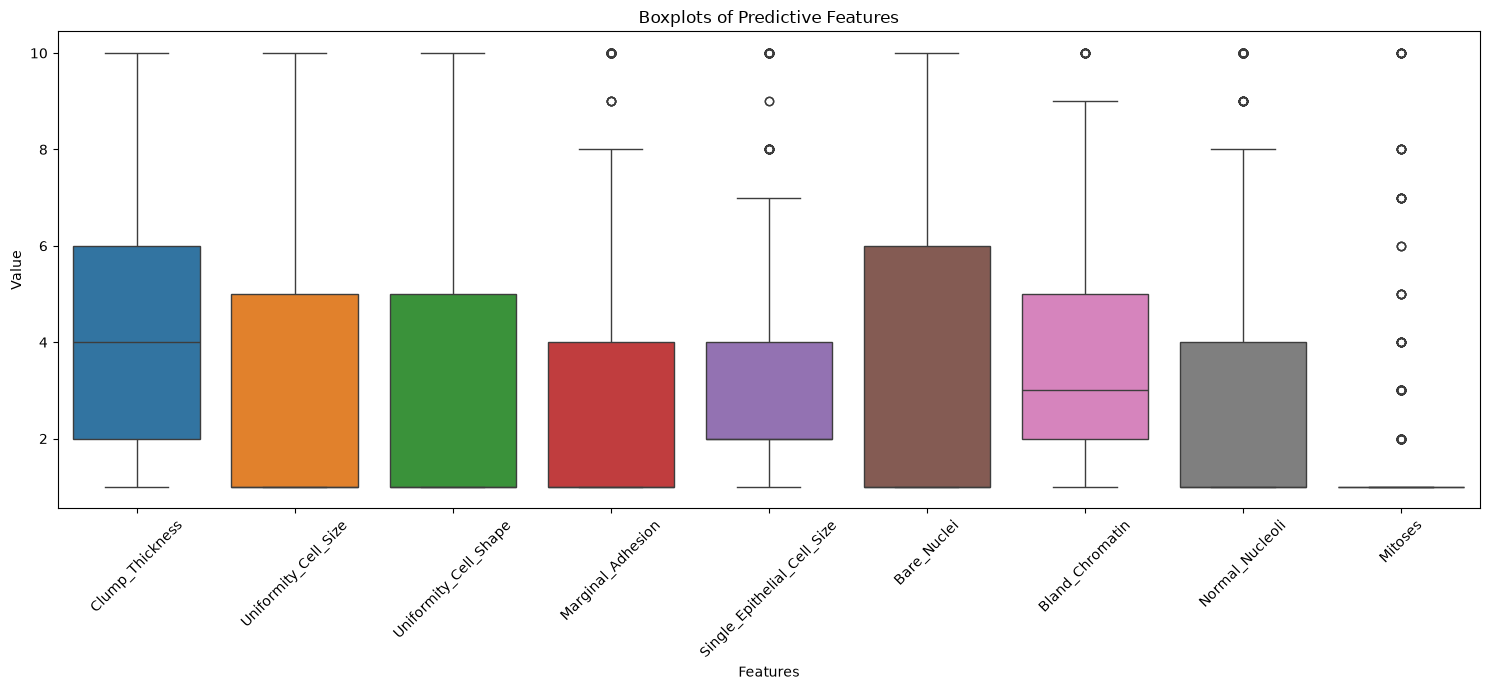

In [12]:
# ============================================
# STEP 10.1 - Create boxplots for the features
# ============================================

plt.figure(figsize=(15, 7))

sns.boxplot(data=df[feature_columns])

plt.title("Boxplots of Predictive Features")
plt.xlabel("Features")
plt.ylabel("Value")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

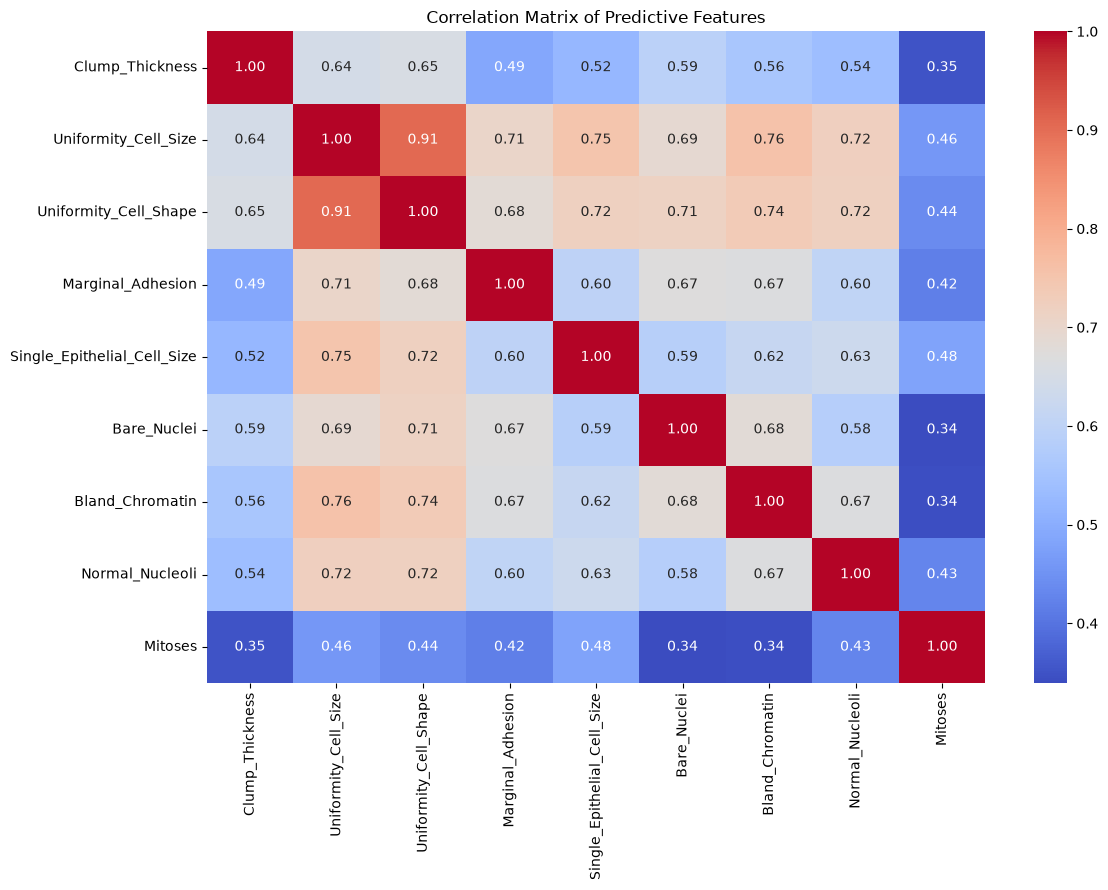

In [13]:
# ============================================
# STEP 11.1 - Create the correlation matrix
# ============================================

correlation_matrix = df[feature_columns].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Predictive Features")

plt.tight_layout()
plt.show()

In [14]:
# ============================================
# STEP 12.1 - Create readable class labels
# ============================================

df["Class_Label"] = df["Class"].map({
    2: "Benign",
    4: "Malignant"
})

df[["Class", "Class_Label"]].head()

,Class,Class_Label
0,2,Benign
1,2,Benign
2,2,Benign
3,2,Benign
4,2,Benign


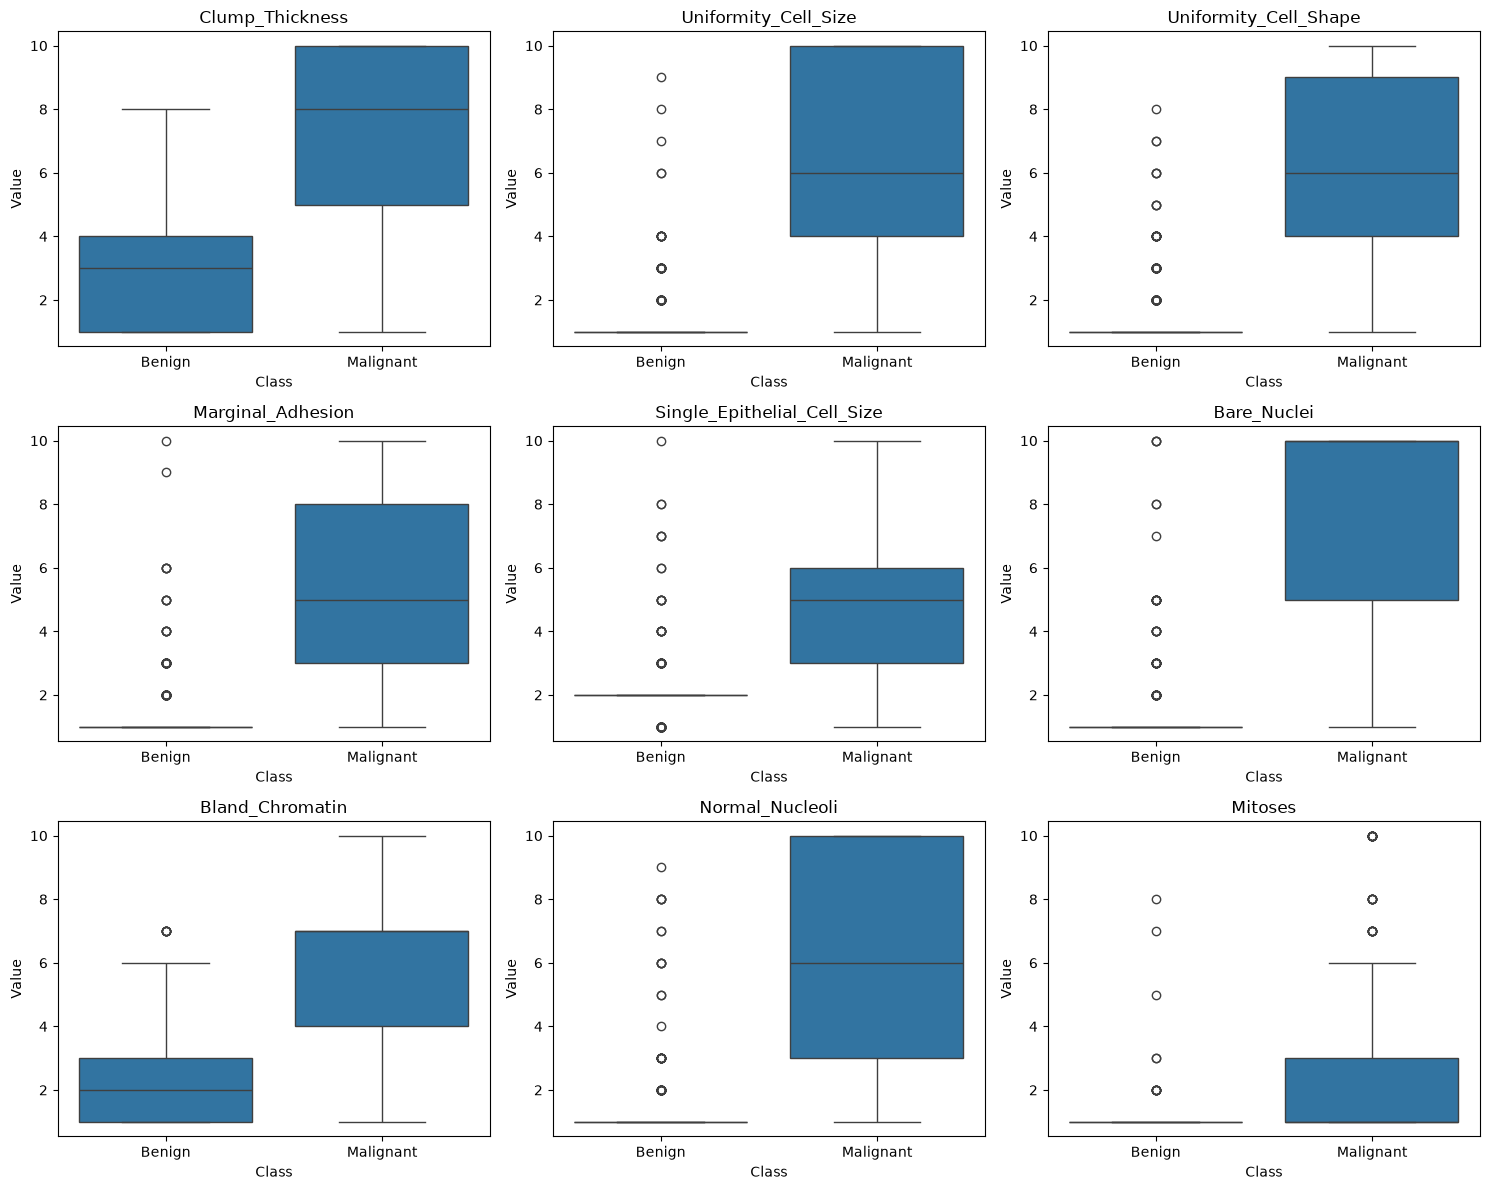

In [15]:
# ============================================
# STEP 13.1 - Compare feature distributions
# between benign and malignant classes
# ============================================

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flatten(), feature_columns):
    sns.boxplot(
        data=df,
        x="Class_Label",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Class")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [20]:
# ============================================
# STEP 14.1 - Save descriptive statistics
# ============================================
# Calculate class_means (adjust 'Class' to match your target column name)
class_means = df.groupby('Class')[feature_columns].mean()

# Save to CSV
class_means.to_csv("results/outputs/class_wise_means.csv")
df[feature_columns].describe().to_csv(
    "results/outputs/descriptive_statistics.csv"
)

class_means.to_csv(
    "results/outputs/class_wise_means.csv"
)

## EDA Summary

The exploratory data analysis was performed to understand the structure, distribution, variability, and relationships within the dataset.

The class distribution showed that benign cases were more common than malignant cases, indicating moderate class imbalance.

The histograms showed that several features were concentrated at lower values, with some features showing skewed distributions.

The boxplots identified some statistical outliers. However, the feature values remained within the valid measurement range of 1 to 10. Therefore, statistical outliers were not automatically removed because they may represent valid observations.

The correlation matrix showed strong positive relationships between several predictive features. The strongest relationship was between Uniformity of Cell Size and Uniformity of Cell Shape, with a correlation of approximately 0.91.

The class-wise analysis showed noticeable differences in the distributions of several features between benign and malignant cases, particularly Uniformity of Cell Size, Uniformity of Cell Shape, Bare Nuclei, and Clump Thickness.

These findings provided useful information for the later feature engineering and machine learning stages.
